In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lire le fichier (corriger : csv ou excel)
data = pd.read_csv('Data1.csv')   # ⚠️ adapte selon ton fichier


data


,YearsExperience,Salary,age
0,1.1,39343.0,33
1,1.3,46205.0,34
2,1.5,37731.0,35
3,2.0,43525.0,36
4,2.2,39891.0,37
5,2.9,56642.0,38
6,3.0,60150.0,39
7,3.2,54445.0,40
8,3.2,64445.0,41
9,3.7,57189.0,42


In [2]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
 2   age              30 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


In [3]:

#  Variables (MULTIPLES)

X = data[['YearsExperience', 'age']]   # plusieurs variables
y = data['Salary']

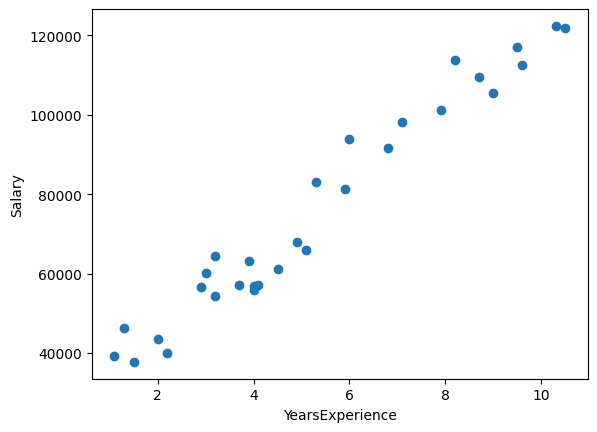

In [4]:
#  Visualisation (optionnel)
plt.scatter(data['YearsExperience'], y)
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [4]:
#  Train / Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=0
)

In [5]:
#  Modèle régression linéaire multiple
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
#  Coefficients
print("Coefficients :", model.coef_)
print("Intercept :", model.intercept_)

Coefficients : [11625.54822055  -706.53712567]
Intercept : 48357.73041631846


In [7]:
#  Prédiction
y_pred = model.predict(X_test)

In [8]:
#  Métriques
from sklearn import metrics

print('MAE :', metrics.mean_absolute_error(y_test, y_pred))
print('MSE :', metrics.mean_squared_error(y_test, y_pred))
print('RMSE :', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R² :', metrics.r2_score(y_test, y_pred))

MAE : 3422.9567815049254
MSE : 21878335.520776205
RMSE : 4677.428302045495
R² : 0.9738986288949385


In [9]:
#  Nouvelle prédiction (exemple)
# Format : [YearsExperience, Age]
NewData = [[5, 30], [4, 25]]
NewTest = pd.DataFrame(NewData, columns=['YearsExperience', 'age'])

y_new = model.predict(NewTest)
print("Nouvelles prédictions :", y_new)

Nouvelles prédictions : [85289.35774888 77196.4951567 ]
